In [2]:

# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

#filter for data analyst data
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

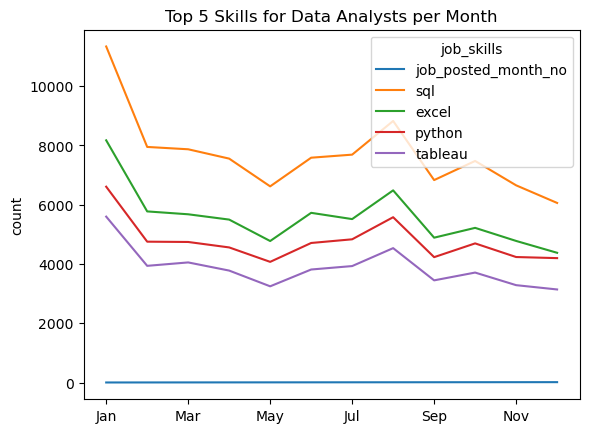

In [ ]:
#create a new col for month no
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

#explode job_skills col
df_DA_exploded = df_DA.explode('job_skills')
#pivot
df_DA_pivot = df_DA_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

#sort skills by count for that we need to calculate total
df_DA_pivot.loc['total'] = df_DA_pivot.sum()
#sort
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['total'].sort_values(ascending=False).index]
#drop total as we created it just for sorting
df_DA_pivot = df_DA_pivot.drop('total')

#use month names for plotting

#to drop month no index reset index 
df_DA_pivot = df_DA_pivot.reset_index()
#convert month_no into name
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x : pd.to_datetime(x, format='%m').strftime('%b'))
#set index month name
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
#drop month no
df_DA_pivot = df_DA_pivot.drop('job_posted_month_no')

#get top 5 skills
df_DA_pivot.iloc[:, :5].plot(kind='line')
plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('count')
plt.xlabel('')
plt.show()


Customization

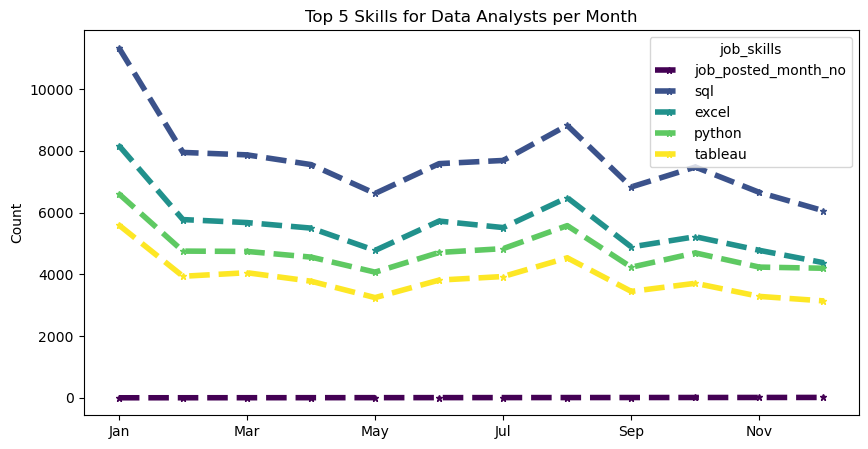

In [17]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle='--', # options: '-', '--', '-.', ':'
    colormap='viridis', # options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis' 
    markersize=5,
    marker='*', # options: 'o', 'x', '+', '*', 's', ',', '.', '1', '2', '3', '4', ...
    figsize=(10, 5)
)

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()